In [1]:
from pygom.model.model_spec import ModelSpec
from pygom.model.transition import Event, Transition

# from pygom.model.ode_variable import State, Parameter, DerivedParameter
# from pygom.model.ode_utils import StateStore, ParameterStore, DerivedParameterStore
# from pygom.model._model_verification import checkEquation

Tests to do:

- Blank fields still work

# States and params

In [2]:
states = ['S', 'I', 'R']
params = ['beta', 'gamma', 'mu']
derived_params = [('N', 'S+I+R')]

mod = ModelSpec(state=states, param=params, derived_param=derived_params)

In [3]:
mod.state_dict

OrderedDict([('S', S), ('I', I), ('R', R)])

In [4]:
mod.parameter_dict

OrderedDict([('beta', beta), ('gamma', gamma), ('mu', mu)])

In [5]:
mod.derived_parameter_dict

OrderedDict([('N', N)])

In [6]:
mod.derived_parameter_expression_dict

OrderedDict([('N', I + R + S)])

In [7]:
mod.states_and_parameters_dict

OrderedDict([('S', S),
             ('I', I),
             ('R', R),
             ('beta', beta),
             ('gamma', gamma),
             ('mu', mu),
             ('N', N),
             ('t', t)])

In [8]:
assert mod.num_state == 3
assert mod.num_param == 3
assert mod.num_derived_param == 1

In [9]:
print(mod.state_lower_limits)
print(mod.state_upper_limits)

[0, 0, 0]
[inf, inf, inf]


# Catch errors?

In [10]:
import pytest

from pygom.model._model_errors import InputError

# Tried to use time (protected parameter)

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma', 't']

    mod = ModelSpec(state=states, param=params)

# Tried to have same state and param name

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma', 'I']

    mod = ModelSpec(state=states, param=params)

# Tried to use state name twice

with pytest.raises(InputError):
    states = ['S', 'I', 'R', 'R']
    params = ['beta', 'gamma']

    mod = ModelSpec(state=states, param=params)

# Tried to define derived parameter without required params

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma']
    derived_params = [('N', 'S+I+R+X')]

    mod = ModelSpec(state=states, param=params, derived_param=derived_params)

# Events and Transitions

In [11]:
states = ['S', 'I', 'R']
params = ['beta', 'gamma', 'mu']
derived_params = [('N', 'S+I+R')]

In [12]:
# Define via events

inf = Event(
    rate='beta*S*I/N',
    transition_list=[Transition(origin='S', destination='I')]
)

rec = Event(
    rate='gamma*I',
    transition_list=[Transition(origin='I', destination='R')]
)

event_list = [inf, rec]

mod1 = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [13]:
# Define via transitions

inf = Transition(origin='S', destination='I', rate='beta*S*I/N')
rec = Transition(origin='I', destination='R', rate='gamma*I')

event_list = [inf, rec]

mod2 = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [14]:
with pytest.raises(InputError):
    states = ['S', 'I']
    params = ['beta']
    inf = Transition(origin='S', destination='I', rate='beta*S*I*zeta')
    event_list = [inf]
    mod = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [15]:
# mod1 == mod2

# Full Model

In [16]:
from pygom.model.pygom_model import Model

states = ['S', 'I', 'R']
params = ['beta', 'gamma']
derived_params = [('N', 'S+I+R')]

inf = Transition(origin='S', destination='I', rate='beta*S*I/N')
rec = Transition(origin='I', destination='R', rate='gamma*I')

event_list = [inf, rec]

mod = Model(state=states, param=params, derived_param=derived_params, event=event_list)

# Maths

## Foundations

In [17]:
mod.state_change_matrix.get_equation()

Matrix([
[-1,  0],
[ 1, -1],
[ 0,  1]])

In [18]:
mod.ode.get_equation()

Matrix([
[          -I*S*beta/N],
[-I*gamma + I*S*beta/N],
[              I*gamma]])

In [19]:
mod.event_rate_vector.get_equation()

Matrix([
[I*S*beta/N],
[   I*gamma]])

## Jacobians

In [20]:
mod.ode_jacobian_params.get_equation()

Matrix([
[-I*S/N,  0],
[ I*S/N, -I],
[     0,  I]])

In [21]:
mod.ode_jacobian_states.get_equation()

Matrix([
[-I*beta/N,         -S*beta/N, 0],
[ I*beta/N, -gamma + S*beta/N, 0],
[        0,             gamma, 0]])

In [22]:
mod.event_rates_jacobian_params.get_equation()

Matrix([
[I*S/N, 0],
[    0, I]])

In [23]:
mod.event_rates_jacobian_states.get_equation()

Matrix([
[I*beta/N, S*beta/N, 0],
[       0,    gamma, 0]])

## Hessian

In [24]:
mod.ode_hessian_params.get_equation()

[Matrix([
 [0, 0],
 [0, 0]]),
 Matrix([
 [0, 0],
 [0, 0]]),
 Matrix([
 [0, 0],
 [0, 0]])]

In [25]:
mod.ode_hessian_states.get_equation()

[Matrix([
 [      0, -beta/N, 0],
 [-beta/N,       0, 0],
 [      0,       0, 0]]),
 Matrix([
 [     0, beta/N, 0],
 [beta/N,      0, 0],
 [     0,      0, 0]]),
 Matrix([
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0]])]

In [26]:
mod.ode_mixed_hessian_states_params.get_equation()

[Matrix([
 [-I/N, 0],
 [-S/N, 0],
 [   0, 0]]),
 Matrix([
 [I/N,  0],
 [S/N, -1],
 [  0,  0]]),
 Matrix([
 [0, 0],
 [0, 1],
 [0, 0]])]

In [27]:
mod.event_rates_hessian_params.get_equation()

[Matrix([
 [0, 0],
 [0, 0]]),
 Matrix([
 [0, 0],
 [0, 0]])]

In [28]:
mod.event_rates_hessian_states.get_equation()

[Matrix([
 [     0, beta/N, 0],
 [beta/N,      0, 0],
 [     0,      0, 0]]),
 Matrix([
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0]])]

In [29]:
mod.event_rates_mixed_hessian_states_params.get_equation()

[Matrix([
 [I/N, 0],
 [S/N, 0],
 [  0, 0]]),
 Matrix([
 [0, 0],
 [0, 1],
 [0, 0]])]

In [30]:
mod.parameters = {
    'gamma': 0.25,
    'beta': 0.3
}

AttributeError: type object 'VariableStore' has no attribute 'values'

# Time scaling with model size

In [28]:
import time
import numpy as np

build_times = []
lookup_times = []

ns = [10_000, 20_000, 30_000, 40_000, 50_000]

for n in ns:
    print(n)
    states = [f'S_{i}' for i in range(n)]

    nrep = 10
    t1 = time.time()
    for i in range(nrep):
        mod = ModelSpec(state=states)
    t2 = time.time()

    build_times.append(t2 - t1)

    nrep = 100
    t1 = time.time()
    for i in range(nrep):
        mod.state_list
    t2 = time.time()

    lookup_times.append(t2 - t1)

10000
20000
30000
40000
50000


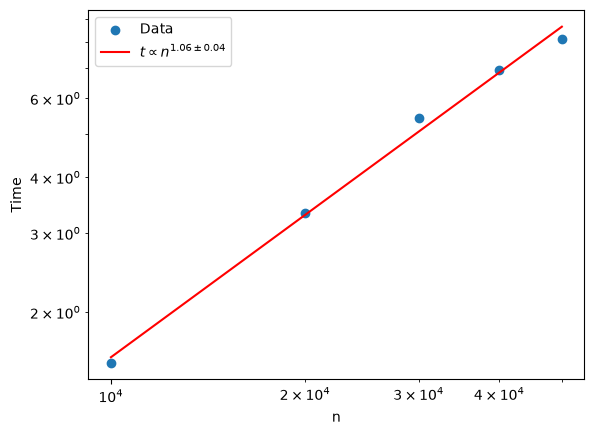

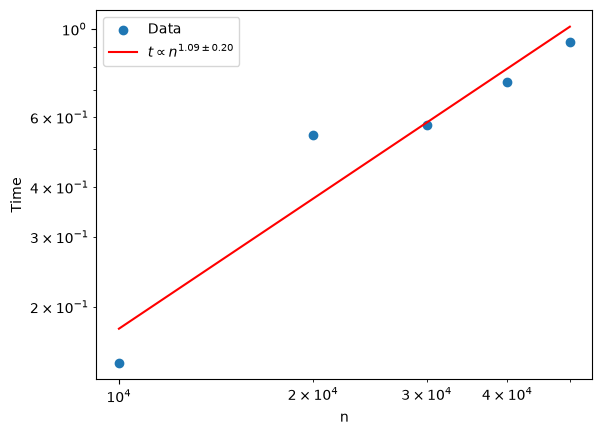

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

def fit_and_plot_time_scaling(ns, times):
    # linear fit in log-log space
    log_n = np.log(ns)
    log_t = np.log(times)

    fit = linregress(log_n, log_t)

    # fitted curve
    n_fit = np.logspace(np.log10(min(ns)), np.log10(max(ns)), 100)
    t_fit = np.exp(fit.intercept) * n_fit**fit.slope

    plt.scatter(ns, times, label="Data")
    plt.plot(n_fit, t_fit, "r",
            label=fr"$t \propto n^{{{fit.slope:.2f}\pm{fit.stderr:.2f}}}$")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel("Time")
    plt.legend()
    plt.show()

fit_and_plot_time_scaling(ns, build_times)
fit_and_plot_time_scaling(ns, lookup_times)

In [30]:
# states = ['S', 'I', 'R']
# params = ['beta', 'gammma', 'mu']
# derived_params = [('N', 'S+I+R')]

# t1 = Transition(origin='S', destination='I', rate='beta*S*I/N')
# t2 = Transition(origin='I', destination='R', rate='gamma*I')

# b1 = Transition(destination='S', rate='N*mu')

# d1 = Transition(origin='S', rate='mu * S')
# d2 = Transition(origin='I', rate='mu * I')
# d3 = Transition(origin='R', rate='mu * R')

# # mod = ModelSpec(state=states, param=params, event=[t1, t2, b1, d1, d2, d3])
# # mod = ModelSpec(state=states)

In [31]:
# _transition_by_orig = {}
# _transition_by_dest = {}

# for event in mod.event_list:
#     for transition in event.transition_list:
#         orig, dest = transition.origin, transition.destination
#         if orig:
#             _transition_by_orig[orig] = {'event_id': event.ID, 'transition_id': transition.ID}
#         if dest:
#             _transition_by_dest[dest] = {'event_id': event.ID, 'transition_id': transition.ID}

# _transition_by_dest